### Flow of EDA for the available files
* Market & Sector indices EDA analysis
* Interest Rates EDA
* CPI & WPI EDA
* News EDA
* Events EDA

In [1]:
import os
import pandas as pd
import numpy as np
import glob


In [2]:
cwd = os.getcwd()
dataset_folder_path = os.path.join(cwd, "..\\data_clean")
files_list = os.listdir(dataset_folder_path)
files_list_path = glob.glob(os.path.join(dataset_folder_path, "*.csv"))
count = 0
for file in files_list_path:
    df = pd.read_csv(file)
    print(f"Reading file:{files_list[count]}")
    print(df.columns)
    print("======================================================")
    count += 1


Reading file:cpi.csv
Index(['Release date', 'Actual', 'Forecast', 'Previous'], dtype='object')
Reading file:events.csv
Index(['Event_id', 'Event_Description', 'date_start', 'end_date',
       'duration_days'],
      dtype='object')
Reading file:interest_rates.csv
Index(['Release date', 'Actual', 'Forecast', 'Previous'], dtype='object')
Reading file:market_index.csv
Index(['date', 'close'], dtype='object')
Reading file:news.csv
Index(['News_id', 'News_Description', 'start_date', 'end_date ', 'duration'], dtype='object')
Reading file:nifty_auto.csv
Index(['date', 'close'], dtype='object')
Reading file:nifty_bank.csv
Index(['date', 'close'], dtype='object')
Reading file:nifty_energy.csv
Index(['date', 'close'], dtype='object')
Reading file:nifty_financial_services.csv
Index(['date', 'close'], dtype='object')
Reading file:nifty_fmcg.csv
Index(['date', 'close'], dtype='object')
Reading file:nifty_it.csv
Index(['date', 'close'], dtype='object')
Reading file:nifty_metal.csv
Index(['date', 'cl

### Analyzing indices data

In [3]:
# Starting with midcap data
market_df_path = os.path.join(dataset_folder_path, "market_index.csv")
market_df = pd.read_csv(market_df_path)
market_df.head()


,date,close
0,01-01-2008,3220.99
1,02-01-2008,3282.05
2,03-01-2008,3284.43
3,04-01-2008,3306.04
4,07-01-2008,3330.91


#### Data Quality Checks
* Missing trading days
* Duplicate dates


In [4]:
print(f"Missing values:\n{market_df.isna().sum()}\n")
print(f"Duplicates count:\n{market_df.duplicated().sum()}\n")


Missing values:
date     0
close    0
dtype: int64

Duplicates count:
0



#### Generating descriptive stats
* Mean Return 
* Median Return 
* Std Dev 
* Min Return 
* Max Return 
* Skewness 
* Kurtosis 


In [5]:
market_df['Return (%)'] = market_df['close'].pct_change() * 100

returns = market_df['Return (%)'].dropna()

stats = {
    'Mean Return (%)': returns.mean(),
    'Median Return (%)': returns.median(),
    'Std Dev (%)': returns.std(),
    'Min Return (%)': returns.min(),
    'Max Return (%)': returns.max(),
    'Skewness': returns.skew(),
    'Kurtosis': returns.kurt()
}

stats_df = pd.DataFrame(stats.items(), columns=['Metric', 'Value'])

print(stats_df.round(4))


              Metric    Value
0    Mean Return (%)   0.0505
1  Median Return (%)   0.1775
2        Std Dev (%)   1.2947
3     Min Return (%) -13.0347
4     Max Return (%)  11.7436
5           Skewness  -0.8924
6           Kurtosis  10.2965


#### Interpretation of above numbers
1.  Daily volatility ~1.3%
2.  Subject to occasional large shocks which we can see from min and max returns
3. Negative Skewness (-0.89)
      * The return distribution is left-skewed.
      * Implications:
            * Large negative returns occur more frequently than equally large positive returns.
            * Downside risk is greater than upside surprise potential.
            * Investors are exposed to occasional sharp losses.
      * More prone to extreme negative events than positive ones

4. Very High Kurtosis (10.30)
      * A normal distribution has kurtosis ≈ 0 (excess kurtosis) or 3 (raw kurtosis, depending on software).
      * A value of 10.3 indicates:
            * Very fat tails.
            * Extreme returns occur much more often than predicted by a normal distribution.
            * 
      * Not normally distributed; tail risk is significant

### Return Analysis
* Daily Return
* Monthly Return
* Yearly Return
* Rolling returns
* Number of +ve vs -ve days returns


In [6]:
market_df.head()


,date,close,Return (%)
0,01-01-2008,3220.99,NaN
1,02-01-2008,3282.05,1.895690
2,03-01-2008,3284.43,0.072516
3,04-01-2008,3306.04,0.657953
4,07-01-2008,3330.91,0.752260


In [7]:
market_df['date'] = pd.to_datetime(market_df['date'], format='%d-%m-%Y')

# Convert percentage return to decimal
market_df['Return_Decimal'] = market_df['Return (%)'] / 100

# Set date as index
market_df = market_df.set_index('date')


In [8]:
monthly_returns = (
    market_df.groupby(pd.Grouper(freq='M'))['close']
    .apply(lambda x: (x.iloc[-1] / x.iloc[0] - 1) * 100)
)
monthly_returns = monthly_returns.reset_index()
monthly_returns.columns = ['Date', 'Monthly Return (%)']

print(monthly_returns)

# Here for June 2026 the monthly return given is based on available data
# of June its not calculated till the last day of june


          Date  Monthly Return (%)
0   2008-01-31          -23.494019
1   2008-02-29           -1.501320
2   2008-03-31          -13.498432
3   2008-04-30           12.775214
4   2008-05-31           -7.412436
..         ...                 ...
217 2026-02-28            3.828332
218 2026-03-31           -9.523776
219 2026-04-30           10.724945
220 2026-05-31            1.877186
221 2026-06-30           -1.549503

[222 rows x 2 columns]


C:\Users\Admin\AppData\Local\Temp\ipykernel_13032\1258433269.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  market_df.groupby(pd.Grouper(freq='M'))['close']


In [9]:
yearly_returns = (
    market_df.groupby(pd.Grouper(freq='Y'))['close']
    .apply(lambda x: (x.iloc[-1] / x.iloc[0] - 1) * 100)
)

yearly_returns = yearly_returns.reset_index()
yearly_returns.columns = ['Year', 'Yearly Return (%)']

print(yearly_returns)

# Here for 2026 the Yearly return given is based on available data  its not calculated till the EOY


         Year  Yearly Return (%)
0  2008-12-31         -66.112593
1  2009-12-31         105.366956
2  2010-12-31          16.559024
3  2011-12-31         -32.690446
4  2012-12-31          44.766540
5  2013-12-31          -4.155139
6  2014-12-31          59.385161
7  2015-12-31           7.982841
8  2016-12-31           4.350076
9  2017-12-31          52.987094
10 2018-12-31         -13.197254
11 2019-12-31          -0.316635
12 2020-12-31          23.943285
13 2021-12-31          45.141639
14 2022-12-31           1.818657
15 2023-12-31          42.661838
16 2024-12-31          23.100035
17 2025-12-31           4.849740
18 2026-12-31          -2.007005


C:\Users\Admin\AppData\Local\Temp\ipykernel_13032\133741633.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  market_df.groupby(pd.Grouper(freq='Y'))['close']


In [10]:
# Descriptive stats about daily, monthly and yearly returns

print("Daily Return Statistics")
print(market_df['Return (%)'].describe())

print("\nMonthly Return Statistics")
print(monthly_returns['Monthly Return (%)'].describe())

print("\nYearly Return Statistics")
print(yearly_returns['Yearly Return (%)'].describe())


Daily Return Statistics
count    4564.000000
mean        0.050476
std         1.294702
min       -13.034674
25%        -0.536434
50%         0.177458
75%         0.736085
max        11.743556
Name: Return (%), dtype: float64

Monthly Return Statistics
count    222.000000
mean       0.785183
std        7.307998
min      -31.619445
25%       -2.718392
50%        1.337432
75%        4.611177
max       40.171044
Name: Monthly Return (%), dtype: float64

Yearly Return Statistics
count     19.000000
mean      16.549148
std       37.431662
min      -66.112593
25%       -1.161820
50%        7.982841
75%       43.714189
max      105.366956
Name: Yearly Return (%), dtype: float64


In [11]:
# Number of +ve,-ve and neutral days

# Positive and negative return days
positive_days = (market_df['Return (%)'] > 0).sum()
negative_days = (market_df['Return (%)'] < 0).sum()
zero_days = (market_df['Return (%)'] == 0).sum()

# To convert days count in % of total
total_days = market_df.shape[0]

print("Positive days %:", positive_days / total_days * 100)
print("Negative days %:", negative_days / total_days * 100)
print("Neutral days %:", zero_days / total_days * 100)


Positive days %: 57.45892661555312
Negative days %: 42.519167579408546
Neutral days %: 0.0


In [ ]:
# Rolling returns computation
window_sizes = [30, 90, 252]  # change to 30,90,252

for window_size in window_sizes:
    market_df[f'Rolling_Return_{window_size}D'] = (
        market_df['Return (%)'] / 100
    ).rolling(window_size).apply(lambda x: (np.prod(1 + x) - 1) * 100, raw=True)


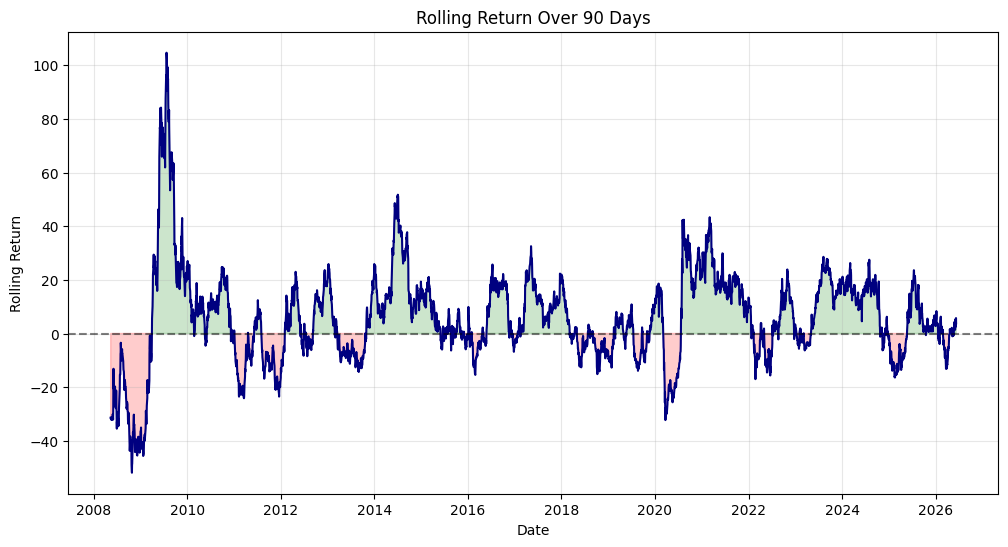

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(market_df.index, market_df['Rolling_Return_90D'], color='navy')

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.fill_between(
    market_df.index,
    market_df['Rolling_Return_90D'],
    0,
    where=market_df['Rolling_Return_90D'] >= 0,
    color='green',
    alpha=0.2
)
plt.fill_between(
    market_df.index,
    market_df['Rolling_Return_90D'],
    0,

    where=market_df['Rolling_Return_90D'] < 0,
    color='red',
    alpha=0.2
)

plt.title('Rolling Return Over 90 Days')
plt.xlabel('Date')
plt.ylabel('Rolling Return')
plt.grid(True, alpha=0.3)
plt.show()


### Volatility Analysis on monthly,quarterly and yearly basis

In [ ]:
# Volatiltiy analysis by computing rolling volatility of 30,90,252 days

for window_size in window_sizes:
    market_df[f'Rolling_Vol_{window_size}D'] = (
        market_df['Return (%)'].rolling(window_size).std()
    )


In [15]:
# Analyzing volatiltiy spikes using z-score method

volatility_z = (
    (market_df['Rolling_Vol_30D'] - market_df['Rolling_Vol_30D'].rolling(252).mean()) /
    market_df['Rolling_Vol_30D'].rolling(252).std()
)
spikes = volatility_z > 2.5
# Getting dates when there were spikes
print("There were spikes at:", market_df[spikes].index)


There were spikes at: DatetimeIndex(['2010-12-13', '2012-03-26', '2012-03-27', '2012-03-28',
               '2013-07-01', '2013-07-02', '2013-07-03', '2013-07-04',
               '2013-07-05', '2013-07-16',
               ...
               '2024-06-27', '2024-06-28', '2024-07-01', '2026-04-08',
               '2026-04-09', '2026-04-10', '2026-04-13', '2026-04-15',
               '2026-04-16', '2026-04-17'],
              dtype='datetime64[ns]', name='date', length=138, freq=None)


In [16]:
# Computing volatiltiy spikes for unusual periods

mean_vol = market_df['Rolling_Vol_30D'].mean()
std_vol = market_df['Rolling_Vol_30D'].std()

threshold = mean_vol + 2 * std_vol

spikes = market_df[market_df['Rolling_Vol_30D'] > threshold]

# Getting dates when there were spikes
print("There were spikes at:", spikes.index)


There were spikes at: DatetimeIndex(['2008-02-12', '2008-02-13', '2008-02-14', '2008-02-15',
               '2008-02-18', '2008-02-19', '2008-02-20', '2008-02-21',
               '2008-02-22', '2008-02-25',
               ...
               '2020-04-24', '2020-04-27', '2020-04-28', '2020-04-29',
               '2020-04-30', '2020-05-04', '2020-05-05', '2020-05-06',
               '2020-05-07', '2020-05-08'],
              dtype='datetime64[ns]', name='date', length=220, freq=None)


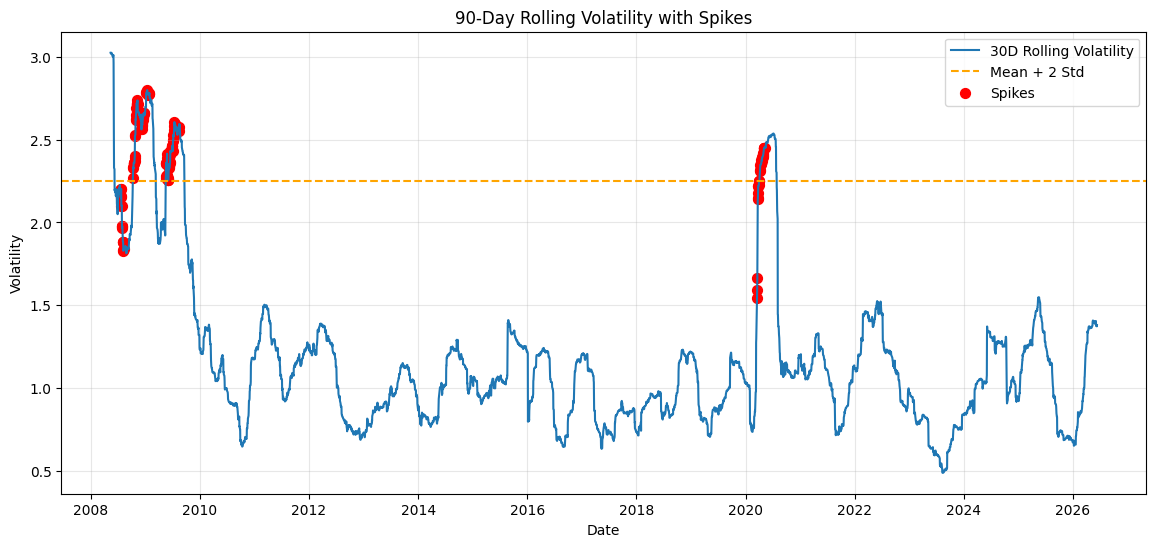

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    market_df.index,
    market_df['Rolling_Vol_90D'],
    label='30D Rolling Volatility'
)

plt.axhline(
    threshold,
    color='orange',
    linestyle='--',
    label='Mean + 2 Std'
)

plt.scatter(
    spikes.index,
    spikes['Rolling_Vol_90D'],
    color='red',
    s=50,
    label='Spikes'
)

plt.title('90-Day Rolling Volatility with Spikes')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


### Drawdown analysis
For doing drawdown analysis we'll find and compute below events:
* Peak
* Trough
* Recovery Time
* Max Drawdown


In [18]:
# Step 1: Compute Running Peak and Drawdown
# Running peak
market_df['Running_Peak'] = market_df['close'].cummax()

# Drawdown (%)
market_df['Drawdown (%)'] = (
    (market_df['close'] - market_df['Running_Peak'])
    / market_df['Running_Peak']) * 100

# Step 2: Find Maximum Drawdown
# Trough = point of maximum drawdown
trough_idx = market_df['Drawdown (%)'].idxmin()
trough_date = trough_idx
trough_value = market_df.loc[trough_idx, 'close']
max_drawdown = market_df.loc[trough_idx, 'Drawdown (%)']


# Step 3: Find Peak Before Trough
peak_idx = market_df.loc[:trough_idx, 'close'].idxmax()
peak_date = peak_idx
peak_value = market_df.loc[peak_idx, 'close']


# Step 4: Find Recovery Date
# Recovery occurs when the index first exceeds the previous peak value.
after_trough = market_df.loc[trough_idx:]
recovery_rows = after_trough[
    after_trough['close'] >= peak_value
]

if len(recovery_rows) > 0:
    # Since here recover rows is a series we use its index[0] to get date as date is its index
    recovery_date = recovery_rows.index[0]
    recovery_days = (
        recovery_date - trough_date
    ).days

else:
    recovery_date = None
    recovery_days = None

# Step 5: Create Summary Table
summary = pd.DataFrame({
    'Metric': [
        'Peak Date',
        'Peak Value',
        'Trough Date',
        'Trough Value',
        'Max Drawdown (%)',
        'Recovery Date',
        'Recovery Time (Days)'
    ],
    'Value': [
        peak_date,
        peak_value,
        trough_date,
        trough_value,
        round(max_drawdown, 2),
        recovery_date,
        recovery_days
    ]
})


print(summary)


                 Metric                Value
0             Peak Date  2008-01-07 00:00:00
1            Peak Value              3330.91
2           Trough Date  2009-03-09 00:00:00
3          Trough Value               887.03
4      Max Drawdown (%)               -73.37
5         Recovery Date  2014-05-23 00:00:00
6  Recovery Time (Days)                 1901


### Sector Analysis
Now that we are done with market analysis we will do sector analysis

In [19]:
def performance_analysis(input_file_path):
    df = pd.read_csv(input_file_path)

    df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

    # =============== Missing value analysis================
    print(f"Missing values:\n{df.isna().sum()}\n")
    print(f"Duplicates count:\n{df.duplicated().sum()}\n")

    # ===============Descriptive stats=====================
    df['Return (%)'] = df['close'].pct_change() * 100

    # Daily returns
    returns = df['Return (%)'].dropna()

    stats = {
        'Mean Return (%)': returns.mean(),
        'Median Return (%)': returns.median(),
        'Std Dev (%)': returns.std(),
        'Min Return (%)': returns.min(),
        'Max Return (%)': returns.max(),
        'Skewness': returns.skew(),
        'Kurtosis': returns.kurt()
    }

    stats_df = pd.DataFrame(stats.items(), columns=['Metric', 'Value'])

    # ===============Return Analysis==================
    # Convert percentage return to decimal
    df['Return_Decimal'] = df['Return (%)'] / 100

    # Set date as index
    df = df.set_index('date')

    # Monthly Returns
    monthly_returns = (
        df.groupby(pd.Grouper(freq='ME'))['close']
        .apply(lambda x: (x.iloc[-1] / x.iloc[0] - 1) * 100)
    )
    monthly_returns = monthly_returns.reset_index()
    monthly_returns.columns = ['Date', 'Monthly Return (%)']

    yearly_returns = (
        df.groupby(pd.Grouper(freq='YE'))['close']
        .apply(lambda x: (x.iloc[-1] / x.iloc[0] - 1) * 100)
    )

    yearly_returns = yearly_returns.reset_index()
    yearly_returns.columns = ['Year', 'Yearly Return (%)']

    # Number of +ve,-ve and neutral days

    # Positive and negative return days
    positive_days = (df['Return (%)'] > 0).sum()
    negative_days = (df['Return (%)'] < 0).sum()
    zero_days = (df['Return (%)'] == 0).sum()

    # To convert days count in % of total
    total_days = df.shape[0]
    positive_days_perc = positive_days / total_days * 100
    negative_days_perc = negative_days / total_days * 100
    zero_days_perc = zero_days / total_days * 100

    # Rolling Returns computation
    # Rolling returns computation
    window_sizes = [30, 90, 252]  # change to 20,30,50,252
    for window_size in window_sizes:
        df[f'Rolling_Return_{window_size}D'] = (
            df['Return (%)'] / 100
        ).rolling(window_size).apply(lambda x: (np.prod(1 + x) - 1) * 100, raw=True)

    # ===================Volatility Analysis =============
    # Volatiltiy analysis by computing rolling volatility of 30,90,252 days

    for window_size in window_sizes:
        df[f'Rolling_Vol_{window_size}D'] = (
            df['Return (%)'].rolling(window_size).std()
        )

    # Analyzing volatiltiy spikes using z-score method
    volatility_z = (
        (df['Rolling_Vol_30D'] - df['Rolling_Vol_30D'].rolling(252).mean()) /
        df['Rolling_Vol_30D'].rolling(252).std()
    )
    spikes_z = volatility_z > 2.5

    # Computing volatiltiy spikes for unusual periods
    mean_vol = df['Rolling_Vol_30D'].mean()
    std_vol = df['Rolling_Vol_30D'].std()

    threshold = mean_vol + 2 * std_vol

    spikes_unusual = df[df['Rolling_Vol_30D'] > threshold]

    # ==================Drawdown Analysis===========
    # Step 1: Compute Running Peak and Drawdown
    # Running peak
    df['Running_Peak'] = df['close'].cummax()

    # Drawdown (%)
    df['Drawdown (%)'] = (
        (df['close'] - df['Running_Peak'])
        / df['Running_Peak']) * 100

    # Step 2: Find Maximum Drawdown
    # Trough = point of maximum drawdown
    trough_idx = df['Drawdown (%)'].idxmin()
    trough_date = trough_idx
    trough_value = df.loc[trough_idx, 'close']
    max_drawdown = df.loc[trough_idx, 'Drawdown (%)']

    # Step 3: Find Peak Before Trough
    peak_idx = df.loc[:trough_idx, 'close'].idxmax()
    peak_date = peak_idx
    peak_value = df.loc[peak_idx, 'close']

    # Step 4: Find Recovery Date
    # Recovery occurs when the index first exceeds the previous peak value.
    after_trough = df.loc[trough_idx:]
    recovery_rows = after_trough[
        after_trough['close'] >= peak_value
    ]

    if len(recovery_rows) > 0:
        # Since here recover rows is a series we use its index[0] to get date as date is its index
        recovery_date = recovery_rows.index[0]
        recovery_days = (
            recovery_date - trough_date
        ).days

    else:
        recovery_date = None
        recovery_days = None

    # Step 5: Create Summary Table
    summary = pd.DataFrame({
        'Metric': [
            'Peak Date',
            'Peak Value',
            'Trough Date',
            'Trough Value',
            'Max Drawdown (%)',
            'Recovery Date',
            'Recovery Time (Days)'
        ],
        'Value': [
            peak_date,
            peak_value,
            trough_date,
            trough_value,
            round(max_drawdown, 2),
            recovery_date,
            recovery_days
        ]
    })

    info_dict = {
        'Dataset': df,
        'Returns Mean': returns.mean(),
        'Returns Median': returns.median(),
        'Returns Std': returns.std(),
        'Min Return': returns.min(),
        'Max Return': returns.max(),
        'Skewness': returns.skew(),
        'Kurtosis': returns.kurt(),
        'Postive Days': positive_days,
        'Negative Days': negative_days,
        'Flat market Days': zero_days,
        'Postive Days(%)': positive_days_perc,
        'Negative Days(%)': negative_days_perc,
        'Flat Days(%)': zero_days_perc,
        'Daily Returns': df['Return (%)'],
        'Monthly Returns': monthly_returns['Monthly Return (%)'],
        'Yearly Returns': yearly_returns['Yearly Return (%)'],
        'Rolling Return 30 Days': df['Rolling_Return_30D'],
        'Rolling Return 90 Days': df['Rolling_Return_90D'],
        'Rolling Return 252 Days': df['Rolling_Return_252D'],
        'Rolling Volatiltiy 30 Days': df['Rolling_Vol_30D'],
        'Rolling Volatiltiy 90 Days': df['Rolling_Vol_90D'],
        'Rolling Volatiltiy 252 Days': df['Rolling_Vol_252D'],
        'Peak Date': peak_date,
        'Spikes gt z': df[spikes_z].index,
        'Spikes Unusual': spikes,
        'Peak Value': peak_value,
        'Trough Date': trough_date,
        'Trough Value': trough_value,
        'Max Drawdown (%)': round(max_drawdown, 2),
        'Recovery Date': recovery_date,
        'Recovery Time (Days)': recovery_days
    }
    return info_dict


In [20]:
nifty_auto_path = os.path.join(dataset_folder_path, "nifty_auto.csv")
print("Nifty auto analysis")
nifty_auto_data = performance_analysis(nifty_auto_path)


nifty_bank_path = os.path.join(dataset_folder_path, "nifty_bank.csv")
print("Nifty bank analysis")
nifty_bank_data = performance_analysis(nifty_bank_path)


nifty_energy_path = os.path.join(dataset_folder_path, "nifty_energy.csv")
print("Nifty energy analysis")
nifty_energy_data = performance_analysis(nifty_energy_path)


Nifty auto analysis
Missing values:
date     0
close    0
dtype: int64

Duplicates count:
0

Nifty bank analysis
Missing values:
date     0
close    0
dtype: int64

Duplicates count:
0

Nifty energy analysis
Missing values:
date     0
close    0
dtype: int64

Duplicates count:
0



In [21]:
nifty_finance_path = os.path.join(dataset_folder_path, "nifty_financial_services.csv")
print("Nifty Financial Services analysis")
nifty_finance_data = performance_analysis(nifty_finance_path)

nifty_fmcg_path = os.path.join(dataset_folder_path, "nifty_fmcg.csv")
print("Nifty FMCG analysis")
nifty_fmcg_data = performance_analysis(nifty_fmcg_path)

nifty_it_path = os.path.join(dataset_folder_path, "nifty_it.csv")
print("Nifty IT analysis")
nifty_it_data = performance_analysis(nifty_it_path)


Nifty Financial Services analysis
Missing values:
date     0
close    0
dtype: int64

Duplicates count:
0

Nifty FMCG analysis
Missing values:
date     0
close    0
dtype: int64

Duplicates count:
0

Nifty IT analysis
Missing values:
date     0
close    0
dtype: int64

Duplicates count:
0



In [22]:
nifty_metal_path = os.path.join(dataset_folder_path, "nifty_metal.csv")
print("Nifty Metal analysis")
nifty_metal_data = performance_analysis(nifty_metal_path)

nifty_pharma_path = os.path.join(dataset_folder_path, "nifty_pharma.csv")
print("Nifty Pharma analysis")
nifty_pharma_data = performance_analysis(nifty_pharma_path)

nifty_realty_path = os.path.join(dataset_folder_path, "nifty_realty.csv")
print("Nifty Realty analysis")
nifty_realty_data = performance_analysis(nifty_realty_path)


market_data_path = os.path.join(dataset_folder_path, "market_index.csv")
print("Market Index analysis")
market_index_data = performance_analysis(market_data_path)


Nifty Metal analysis
Missing values:
date     0
close    0
dtype: int64

Duplicates count:
0

Nifty Pharma analysis
Missing values:
date     0
close    0
dtype: int64

Duplicates count:
0

Nifty Realty analysis
Missing values:
date     0
close    0
dtype: int64

Duplicates count:
0

Market Index analysis
Missing values:
date     0
close    0
dtype: int64

Duplicates count:
0



### Correlation Analysis
Now that we have all the required data about indices we will do:
* Market - Sector Correlation Analysis
* Sector - Sector Correlation Analysis

#### Daily returns analysis

In [23]:
returns_df = pd.concat([
    market_index_data['Daily Returns'].rename('market'),
    nifty_auto_data['Daily Returns'].rename('nifty_auto'),
    nifty_bank_data['Daily Returns'].rename('nifty_bank'),
    nifty_energy_data['Daily Returns'].rename('nifty_energy'),
    nifty_finance_data['Daily Returns'].rename('nifty_finance'),
    nifty_fmcg_data['Daily Returns'].rename('nifty_fmcg'),
    nifty_it_data['Daily Returns'].rename('nifty_it'),
    nifty_metal_data['Daily Returns'].rename('nifty_metal'),
    nifty_pharma_data['Daily Returns'].rename('nifty_pharma'),
    nifty_realty_data['Daily Returns'].rename('nifty_realty')
], axis=1)

returns_df.reset_index(names='date', inplace=True)


In [24]:
returns_corr = returns_df.corr()
returns_corr['market'].sort_values()


date             0.024679
nifty_it         0.503482
nifty_fmcg       0.585761
nifty_pharma     0.599027
nifty_energy     0.726458
nifty_metal      0.770799
nifty_bank       0.774738
nifty_auto       0.778106
nifty_finance    0.783816
nifty_realty     0.815360
market           1.000000
Name: market, dtype: float64

#### Observations
* As we can see IT,FMCG & Pharma which are generally considered as defensive sectors are having moderately correlated with midcap index
* While Realty,Financical Services,Automobiles, Bank and Metal have strong correlation with Midcap Index

In [25]:
index_columns = returns_df.columns
sectors_corr_list = {}
# Finding strong sector - sector correlation
for sector in index_columns:
    if sector == 'date' or sector == 'market':
        continue

    sector_corr = returns_corr[sector]
    strong_corr = sector_corr[sector_corr >= 0.7]
    sectors_corr_list[sector] = strong_corr

for sector, sectors_list in sectors_corr_list.items():
    print(f"\nFor {sector} below are the strongly correlated sectors")
    print(sectors_list)



For nifty_auto below are the strongly correlated sectors
market           0.778106
nifty_auto       1.000000
nifty_finance    0.707571
Name: nifty_auto, dtype: float64

For nifty_bank below are the strongly correlated sectors
market           0.774738
nifty_bank       1.000000
nifty_finance    0.973315
nifty_realty     0.709011
Name: nifty_bank, dtype: float64

For nifty_energy below are the strongly correlated sectors
market          0.726458
nifty_energy    1.000000
Name: nifty_energy, dtype: float64

For nifty_finance below are the strongly correlated sectors
market           0.783816
nifty_auto       0.707571
nifty_bank       0.973315
nifty_finance    1.000000
nifty_realty     0.716819
Name: nifty_finance, dtype: float64

For nifty_fmcg below are the strongly correlated sectors
nifty_fmcg    1.0
Name: nifty_fmcg, dtype: float64

For nifty_it below are the strongly correlated sectors
nifty_it    1.0
Name: nifty_it, dtype: float64

For nifty_metal below are the strongly correlated s

### Summary of strong sector to sector relations
* Auto : Financial Services
* Bank: Financial Services, Realty
* Energy: None
* Financial Services: Auto, Bank and Realty
* FMCG: None
* IT: None
* Pharma: None
* Metal: None
* Realty: Bank & Financial Services

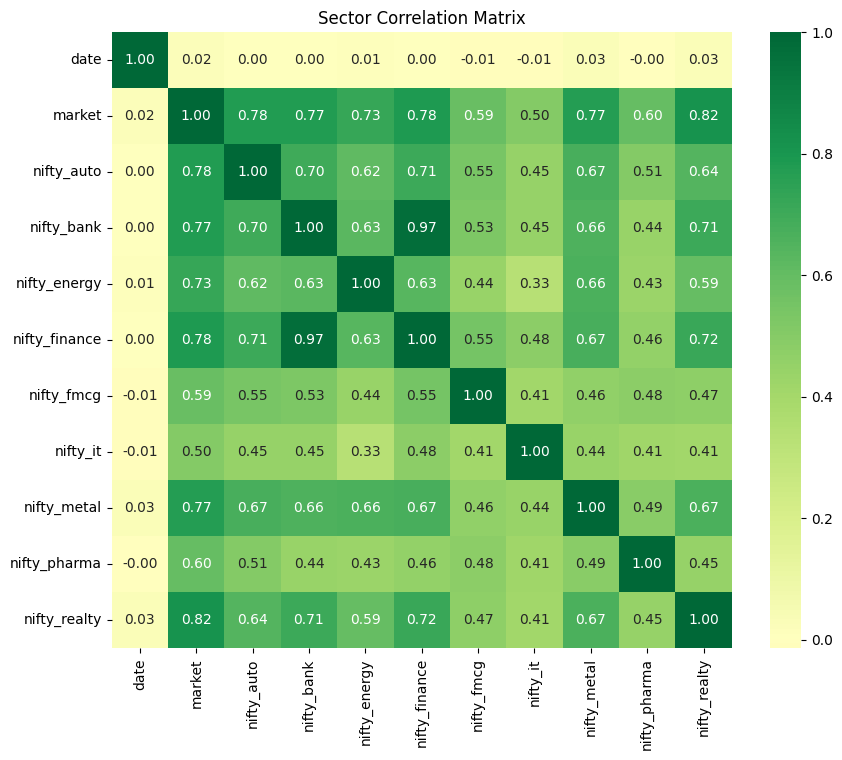

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(
    returns_corr,
    annot=True,
    cmap='RdYlGn',
    center=0,
    fmt='.2f'
)

plt.title('Sector Correlation Matrix')
plt.show()


### Monthly Correlation Analysis

In [27]:
monthly_returns_df = pd.concat([
    market_index_data['Monthly Returns'].rename('market'),
    nifty_auto_data['Monthly Returns'].rename('nifty_auto'),
    nifty_bank_data['Monthly Returns'].rename('nifty_bank'),
    nifty_energy_data['Monthly Returns'].rename('nifty_energy'),
    nifty_finance_data['Monthly Returns'].rename('nifty_finance'),
    nifty_fmcg_data['Monthly Returns'].rename('nifty_fmcg'),
    nifty_it_data['Monthly Returns'].rename('nifty_it'),
    nifty_metal_data['Monthly Returns'].rename('nifty_metal'),
    nifty_pharma_data['Monthly Returns'].rename('nifty_pharma'),
    nifty_realty_data['Monthly Returns'].rename('nifty_realty')
], axis=1)

monthly_returns_df.reset_index(names='date', inplace=True)


In [28]:
monthly_returns_corr = returns_df.corr()
monthly_returns_corr[monthly_returns_corr >= 0.7]


,date,market,nifty_auto,nifty_bank,nifty_energy,nifty_finance,nifty_fmcg,nifty_it,nifty_metal,nifty_pharma,nifty_realty
date,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
market,NaN,1.000000,0.778106,0.774738,0.726458,0.783816,NaN,NaN,0.770799,NaN,0.815360
nifty_auto,NaN,0.778106,1.000000,NaN,NaN,0.707571,NaN,NaN,NaN,NaN,NaN
nifty_bank,NaN,0.774738,NaN,1.000000,NaN,0.973315,NaN,NaN,NaN,NaN,0.709011
nifty_energy,NaN,0.726458,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
nifty_finance,NaN,0.783816,0.707571,0.973315,NaN,1.000000,NaN,NaN,NaN,NaN,0.716819
nifty_fmcg,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
nifty_it,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
nifty_metal,NaN,0.770799,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
nifty_pharma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN


#### Rolling Returns Correlation Analysis

In [29]:
# Market to Sector Rolling Returns analysis
window = 90
rolling_corr_mean = {}

for col in returns_df.columns:
    if col != 'market' and col != 'date':
        rc = returns_df['market'].rolling(window).corr(returns_df[col])
        rolling_corr_mean[col] = rc.mean()

rolling_corr_df = pd.DataFrame.from_dict(
    rolling_corr_mean,
    orient='index',
    columns=['Avg Rolling Corr']
)


In [30]:
window = 90

corr_matrix = pd.DataFrame(
    index=returns_df.columns,
    columns=returns_df.columns,
    dtype=float
)

for col1 in returns_df.columns:
    if col1 == 'date' or col1 == 'market':
        continue
    for col2 in returns_df.columns:
        if col2 == 'date' or col2 == 'market' or col2 == col1:
            continue

        rc = (
            returns_df[col1]
            .rolling(window)
            .corr(returns_df[col2])
        )
        if rc.mean() >= 0.65:
            corr_matrix.loc[col1, col2] = rc.mean()

corr_matrix


,date,market,nifty_auto,nifty_bank,nifty_energy,nifty_finance,nifty_fmcg,nifty_it,nifty_metal,nifty_pharma,nifty_realty
date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
market,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nifty_auto,NaN,NaN,NaN,0.658125,NaN,0.664493,NaN,NaN,NaN,NaN,NaN
nifty_bank,NaN,NaN,0.658125,NaN,NaN,0.962276,NaN,NaN,NaN,NaN,NaN
nifty_energy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nifty_finance,NaN,NaN,0.664493,0.962276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nifty_fmcg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nifty_it,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nifty_metal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nifty_pharma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Volatility Analysis

In [31]:
volatility_90D_df = pd.concat([
    market_index_data['Rolling Volatiltiy 90 Days'].rename('market'),
    nifty_auto_data['Rolling Volatiltiy 90 Days'].rename('nifty_auto'),
    nifty_bank_data['Rolling Volatiltiy 90 Days'].rename('nifty_bank'),
    nifty_energy_data['Rolling Volatiltiy 90 Days'].rename('nifty_energy'),
    nifty_finance_data['Rolling Volatiltiy 90 Days'].rename('nifty_finance'),
    nifty_fmcg_data['Rolling Volatiltiy 90 Days'].rename('nifty_fmcg'),
    nifty_it_data['Rolling Volatiltiy 90 Days'].rename('nifty_it'),
    nifty_metal_data['Rolling Volatiltiy 90 Days'].rename('nifty_metal'),
    nifty_pharma_data['Rolling Volatiltiy 90 Days'].rename('nifty_pharma'),
    nifty_realty_data['Rolling Volatiltiy 90 Days'].rename('nifty_realty')
], axis=1)

volatility_90D_df.reset_index(names='date', inplace=True)


In [32]:
vol_90D_corr = volatility_90D_df.corr()
# Finding only highly correlated volatilie indices
vol_90D_corr[vol_90D_corr > 0.7]


,date,market,nifty_auto,nifty_bank,nifty_energy,nifty_finance,nifty_fmcg,nifty_it,nifty_metal,nifty_pharma,nifty_realty
date,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
market,NaN,1.000000,0.869283,0.883514,0.892990,0.908399,0.850098,0.897905,0.920180,0.773069,0.872529
nifty_auto,NaN,0.869283,1.000000,0.855207,0.786722,0.862879,0.828591,0.795808,0.840730,0.772797,0.700338
nifty_bank,NaN,0.883514,0.855207,1.000000,0.787696,0.995066,0.864498,0.871618,0.892742,0.706164,0.873142
nifty_energy,NaN,0.892990,0.786722,0.787696,1.000000,0.825843,0.709832,0.732360,0.832854,NaN,NaN
nifty_finance,NaN,0.908399,0.862879,0.995066,0.825843,1.000000,0.879815,0.899633,0.903731,0.721772,0.885398
nifty_fmcg,NaN,0.850098,0.828591,0.864498,0.709832,0.879815,1.000000,0.801827,0.790709,0.774045,0.773109
nifty_it,NaN,0.897905,0.795808,0.871618,0.732360,0.899633,0.801827,1.000000,0.873248,NaN,0.852596
nifty_metal,NaN,0.920180,0.840730,0.892742,0.832854,0.903731,0.790709,0.873248,1.000000,0.725036,0.884413
nifty_pharma,NaN,0.773069,0.772797,0.706164,NaN,0.721772,0.774045,NaN,0.725036,1.000000,NaN


### Observation
For correlation >0.7 it means volatility spikes occur simultaneously.

In [33]:
from scipy.stats import pearsonr

sectors_list = returns_df.columns
significance_list = {}
for col1 in sectors_list:
    if col1 == 'date':
        continue

    for col2 in sectors_list:
        if col2 == 'date' or col1 == col2:
            continue

        temp = returns_df[[col1, col2]].dropna()
        corr, pvalue = pearsonr(temp[col1], temp[col2])
        if corr >= 0.7:
            significance_list[f'{col1} - {col2}'] = f'Correlation:{corr:.6f},P-value:{pvalue:.20e}'
significance_list


{'market - nifty_auto': 'Correlation:0.778106,P-value:0.00000000000000000000e+00',
 'market - nifty_bank': 'Correlation:0.774738,P-value:0.00000000000000000000e+00',
 'market - nifty_energy': 'Correlation:0.726458,P-value:0.00000000000000000000e+00',
 'market - nifty_finance': 'Correlation:0.783816,P-value:0.00000000000000000000e+00',
 'market - nifty_metal': 'Correlation:0.770799,P-value:0.00000000000000000000e+00',
 'market - nifty_realty': 'Correlation:0.815360,P-value:0.00000000000000000000e+00',
 'nifty_auto - market': 'Correlation:0.778106,P-value:0.00000000000000000000e+00',
 'nifty_auto - nifty_finance': 'Correlation:0.707571,P-value:0.00000000000000000000e+00',
 'nifty_bank - market': 'Correlation:0.774738,P-value:0.00000000000000000000e+00',
 'nifty_bank - nifty_finance': 'Correlation:0.973315,P-value:0.00000000000000000000e+00',
 'nifty_bank - nifty_realty': 'Correlation:0.709011,P-value:0.00000000000000000000e+00',
 'nifty_energy - market': 'Correlation:0.726458,P-value:0.0

### Comparing sectors & market indices over all performance & metrics

In [34]:
indices_dict = {
    'Nifty_Midcap': market_index_data,
    'Nifty_Auto': nifty_auto_data,
    'Nifty_Bank': nifty_bank_data,
    'Nifty_Energy': nifty_energy_data,
    'Nifty_Financial_Services': nifty_finance_data,
    'Nifty_FMCG': nifty_fmcg_data,
    'Nifty_IT': nifty_it_data,
    'Nifty_Metal': nifty_metal_data,
    'Nifty_Pharma': nifty_pharma_data,
    'Nifty_Realty': nifty_realty_data
}

exclude_keys = {
    'Daily Returns',
    'Monthly Returns',
    'Yearly Returns',
    'Rolling Return 30 Days',
    'Rolling Return 90 Days',
    'Rolling Return 252 Days',
    'Rolling Volatiltiy 30 Days',
    'Rolling Volatiltiy 90 Days',
    'Rolling Volatiltiy 252 Days',
    'Spikes gt z',
    'Spikes Unusual'
}

rows = []

for index_name, info_dict in indices_dict.items():
    row = {}

    for key, value in info_dict.items():
        if key in exclude_keys:
            continue

        # optional: skip non-scalar types safely
        if isinstance(value, (pd.Series, pd.DataFrame, list, dict)):
            continue

        row[key] = value

    row['Index'] = index_name  # add identifier
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Index')


In [35]:
summary_df


,Returns Mean,Returns Median,Returns Std,Min Return,Max Return,Skewness,Kurtosis,Postive Days,Negative Days,Flat market Days,Postive Days(%),Negative Days(%),Flat Days(%),Peak Date,Peak Value,Trough Date,Trough Value,Max Drawdown (%),Recovery Date,Recovery Time (Days)
Index,,,,,,,,,,,,,,,,,,,,
Nifty_Midcap,0.050476,0.177458,1.294702,-13.034674,11.743556,-0.892355,10.296465,2623,1941,0,57.458927,42.519168,0.000000,2008-01-07,3330.91,2009-03-09,887.03,-73.37,2014-05-23,1901.0
Nifty_Auto,0.062760,0.075929,1.439360,-13.847844,15.032680,-0.033906,8.288628,2418,2133,9,53.014690,46.766060,0.197325,2017-12-29,12009.70,2020-04-03,4517.75,-62.38,2021-11-17,593.0
Nifty_Bank,0.052042,0.071856,1.703066,-16.734014,18.814585,0.089668,9.885401,2405,2159,1,52.671923,47.284275,0.021901,2008-01-14,10698.35,2009-03-09,3339.70,-68.78,2010-08-13,522.0
Nifty_Energy,0.048278,0.076596,1.304547,-12.465247,8.634415,-0.550077,6.354189,2006,1792,2,52.775585,47.145488,0.052618,2019-06-03,16760.15,2020-03-23,9850.50,-41.23,2020-12-03,255.0
Nifty_Financial_Services,0.052313,0.065534,1.659326,-15.938594,19.490719,0.106420,10.819351,2391,2165,5,52.411223,47.457256,0.109601,2008-01-14,4607.18,2009-03-09,1382.52,-69.99,2010-09-13,553.0
Nifty_FMCG,0.050897,0.065784,1.144848,-10.595374,8.658282,-0.131090,7.060803,2404,2156,1,52.696186,47.259974,0.021920,2008-01-07,6778.92,2008-10-27,4362.96,-35.64,2009-07-27,273.0
Nifty_IT,0.050410,0.045199,1.537465,-11.741790,12.434799,-0.063160,6.038568,2361,2198,2,51.753617,48.180623,0.043840,2008-01-01,4748.20,2009-03-03,2002.00,-57.84,2009-08-27,177.0
Nifty_Metal,0.038394,0.064888,1.986183,-12.576500,17.570577,-0.158589,4.689331,2366,2183,13,51.851852,47.841332,0.284900,2008-01-04,5493.95,2008-11-20,1188.78,-78.36,2021-05-10,4554.0
Nifty_Pharma,0.052099,0.057186,1.218314,-8.926873,11.805282,-0.060816,6.758504,2392,2166,3,52.433143,47.479176,0.065761,2015-04-08,13831.15,2020-03-23,6432.30,-53.49,2021-05-10,413.0


### Observation
Nifty Realty has not recovered even in June 2026 from its peak on **14-01-2008**